Insurance dataset is a data set about predicting the amount of insurance to pay for a patient, which includes the following features:
- age: Age of the patient, is a positive integer value
- sex: Patient's gender where 0 is male, 1 is female
- bmi: The patient's BMI, is the actual value
- children: Number of children of the patient, is a positive integer value
- smoker: Indicates whether the patient smokes, where 1 is yes and 0 is no
- region: Indicate the region the patient is in, 0 is southwest 1 is southeast 2 is northwest and 3 is northeast

- charges: Individual medical costs billed by health insurance.

In [2]:
#import library
import pandas as pd # pandas
import numpy as np # numpy
import time


In [36]:
#Download Dataset
!wget https://raw.githubusercontent.com/huynhthanh98/data__/refs/heads/main/Insurance.csv

--2026-04-06 17:17:21--  https://raw.githubusercontent.com/huynhthanh98/data__/refs/heads/main/Insurance.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 3117837 (3.0M) [text/plain]
Saving to: ‘Insurance.csv.1’

Insurance.csv.1     100%[===================>]   2.97M  --.-KB/s    in 0.03s   

2026-04-06 17:17:21 (112 MB/s) - ‘Insurance.csv.1’ saved [3117837/3117837]



In [37]:
!gdown 1sLbhw9Oevzg5Z35ZZtpTygi9ASDOw4sZ

Downloading...
From: https://drive.google.com/uc?id=1sLbhw9Oevzg5Z35ZZtpTygi9ASDOw4sZ
To: /content/Insurance.csv
100% 3.12M/3.12M [00:00<00:00, 175MB/s]


# Prepare and Analyze Data

1. Load Dataset
2. Analyze Dataset
3. Preprocess data (type, null, missing, ...)
4. Feature Engineering

## Load Dataset

When loading datasets with `pd.read_csv`, you should be aware of several important parameters:

*   `filepath_or_buffer`: The path to the CSV file.
*   `sep`: The delimiter used in the CSV file (e.g., ',' for comma-separated, '\t' for tab-separated). Default is ','.
*   `header`: Row number(s) to use as the column names. Default is 0 (the first row).
*   `index_col`: Column(s) to use as the row labels of the DataFrame. Can be a column name or column index.
*   `na_values`: Additional strings to recognize as `NaN` (Not a Number).
*   `dtype`: Dictionary specifying column data types (e.g., `{'col_name': 'int64'}`).
*   `parse_dates`: List of column names to parse as dates.

In [38]:
# read data using Pandas DataFrame
def read_dataset(path):
    # read data using Pandas DataFrame
    df = pd.read_csv(path)
    display(df.head())
    print("\nDataFrame Info:")
    print(df.info())
    print("\nDataFrame Shape:", df.shape)
    display(df.describe())
    return df

In [39]:
df = read_dataset("/content/Insurance.csv")

,age,sex,bmi,children,smoker,region,charges
0,43,female,25.800,0,yes,northwest,31128.291496
1,43,female,28.600,2,no,southwest,8739.200017
2,34,female,37.290,4,no,northeast,10979.246131
3,50,female,42.370,3,no,southeast,15278.753423
4,26,female,29.595,1,no,northeast,5153.591905



DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 59333 entries, 0 to 59332
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       59333 non-null  int64  
 1   sex       59333 non-null  object 
 2   bmi       59333 non-null  float64
 3   children  59333 non-null  int64  
 4   smoker    59333 non-null  object 
 5   region    59333 non-null  object 
 6   charges   59333 non-null  float64
dtypes: float64(2), int64(2), object(3)
memory usage: 3.2+ MB
None

DataFrame Shape: (59333, 7)


,age,bmi,children,charges
count,59333.000000,59333.000000,59333.000000,59333.000000
mean,40.791448,30.930536,1.107411,13459.312130
std,13.897712,6.121275,1.455713,10175.464573
min,18.000000,15.815000,-1.000000,0.375242
25%,28.000000,26.510000,0.000000,6449.205453
50%,42.000000,30.600000,1.000000,10570.434369
75%,52.000000,35.000000,2.000000,15058.323202
max,65.000000,54.130000,6.000000,63770.428010


## Data Analysis

### 1. Checking for Missing Data
It is essential to check for null values before modeling. We use `.isnull().sum()` to identify any columns that require data imputation.

In [45]:
# Check for missing values in the dataset
print("Missing values summary:")
display(df.isnull().sum())

Missing values summary:


,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


### 2. Distribution of Target Variable
We visualize the distribution of `charges` to understand its spread and identify if there is a significant skew, which might affect linear regression performance.

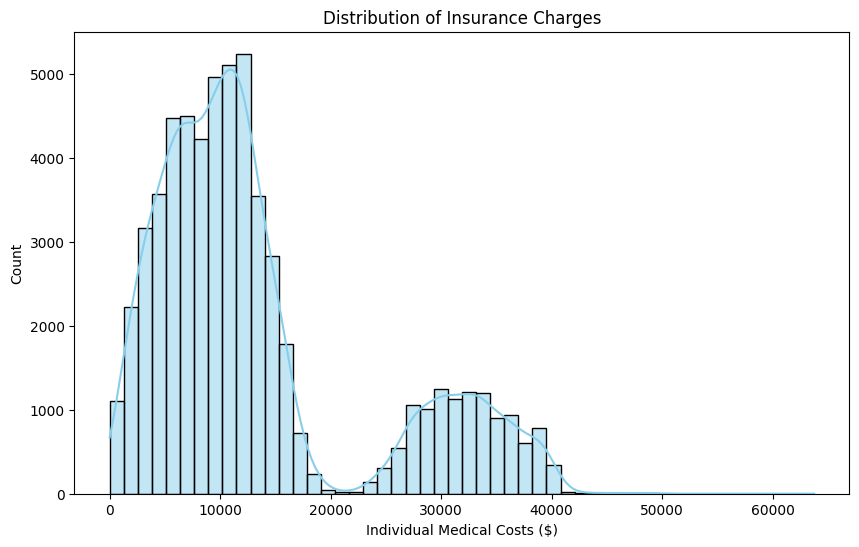

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.histplot(df['charges'], kde=True, bins=50, color='skyblue')
plt.title('Distribution of Insurance Charges')
plt.xlabel('Individual Medical Costs ($)')
plt.ylabel('Count')
plt.show()

### 3. Analyzing Categorical Features
Boxplots are excellent for teaching students how binary or categorical features (like smoking status) impact the target variable.

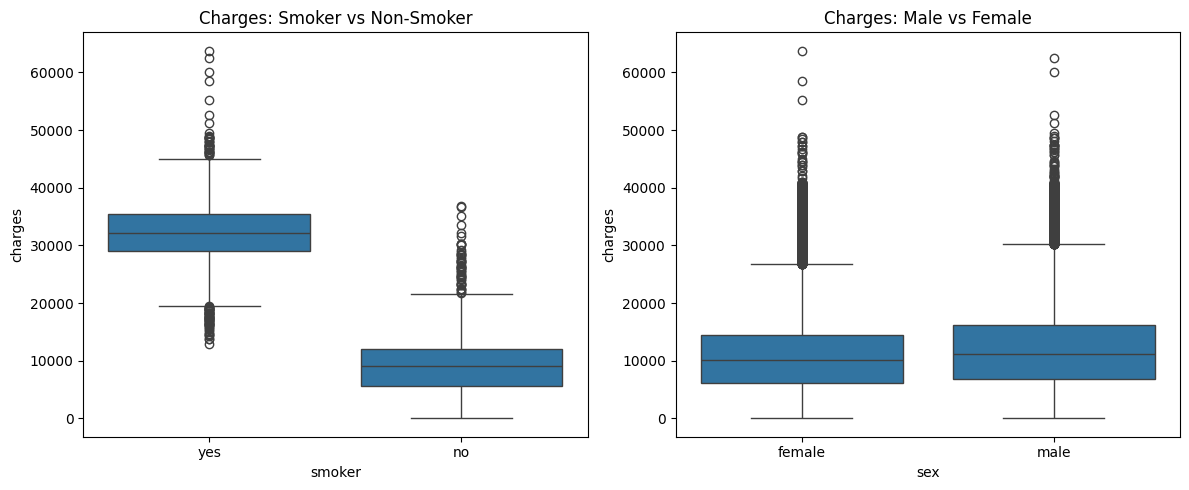

In [9]:
# Comparative analysis using boxplots
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.boxplot(x='smoker', y='charges', data=df)
plt.title('Charges: Smoker vs Non-Smoker')

plt.subplot(1, 2, 2)
sns.boxplot(x='sex', y='charges', data=df)
plt.title('Charges: Male vs Female')

plt.tight_layout()
plt.show()

<Axes: xlabel='charges', ylabel='Count'>

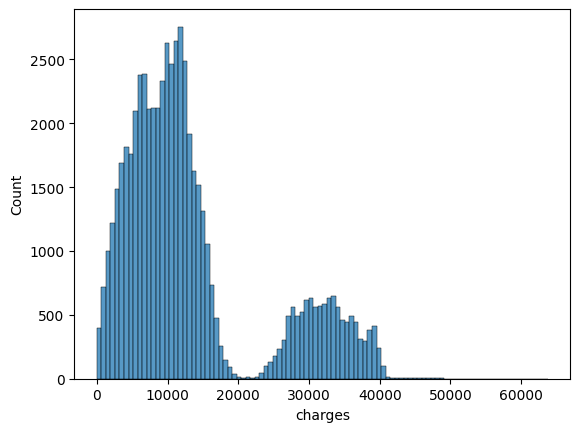

In [10]:
import seaborn as sns
sns.histplot(x="charges", data=df, bins=100)

## Preprocessing

In [11]:
# --- (Optional) Drop null datapoints or fill missing data
# print("Sample size:", len(df))
# df = df.dropna() <=> df.dropna(inplace=True)
# df = df.dropna()
# print("Not null sample size:", len(df))

In [12]:
def preprocessing_data(df):
    # --- (Optional) Drop null datapoints or fill missing data
    # Keep your data the same if you dont want to customize it
    df = df
    return df

In [13]:
df = preprocessing_data(df.copy())

## Feature Engineering

In [46]:
def normalize_data(df):
    # data normalization
    normalized_data = df.copy()
    normalized_data["sex"] = normalized_data["sex"].astype("category").cat.codes
    normalized_data["smoker"] = normalized_data["smoker"].astype("category").cat.codes
    normalized_data["region"] = normalized_data["region"].astype("category").cat.codes

    display(normalized_data.head())
    display(normalized_data.corr())
    return normalized_data


,age,sex,bmi,children,smoker,region,charges
0,43,0,25.800,0,1,1,31128.291496
1,43,0,28.600,2,0,3,8739.200017
2,34,0,37.290,4,0,0,10979.246131
3,50,0,42.370,3,0,2,15278.753423
4,26,0,29.595,1,0,0,5153.591905


,age,sex,bmi,children,smoker,region,charges
age,1.000000,-0.004123,0.091252,0.008060,-0.029931,0.007996,0.331857
sex,-0.004123,1.000000,0.049948,0.017484,0.080734,0.015634,0.084363
bmi,0.091252,0.049948,1.000000,0.030296,0.002000,0.149486,0.202631
children,0.008060,0.017484,0.030296,1.000000,0.002852,0.021358,0.087100
smoker,-0.029931,0.080734,0.002000,0.002852,1.000000,0.031686,0.909658
region,0.007996,0.015634,0.149486,0.021358,0.031686,1.000000,0.024945
charges,0.331857,0.084363,0.202631,0.087100,0.909658,0.024945,1.000000


<Axes: >

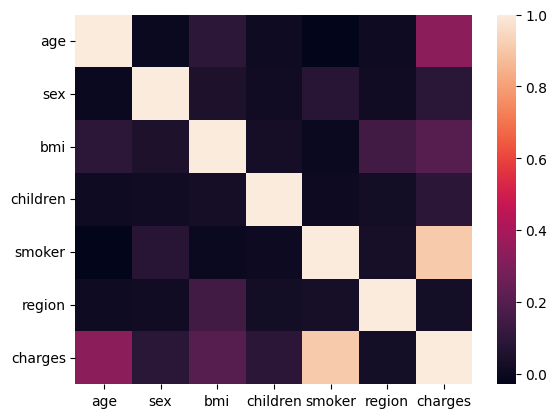

In [47]:
# Heatmap
import seaborn as sns

normalized_data = normalize_data(df)
sns.heatmap(normalized_data.corr())

# Apply machine learning model

## Train-test split

In [48]:
columns = df.columns.tolist()
columns

['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges']

In [49]:
def prepare_X_y(df):
    ## Split X, y from dataset
    columns = df.columns.tolist()     # Columns name
    columns.remove('charges')           # Remove y label (column charges in this case)
    # columns = ["smoker_yes", "bmi", "age"]
    X = df[columns]        # X
    y = df.charges          # y
    return X, y

X, y = prepare_X_y(normalized_data)

In [52]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error



def split_train_test(X, y, train_size=0.7):
    trainX, testX ,trainY, testY = train_test_split(X, y, train_size=train_size, random_state=2026)
    print('Training:' + str(trainX.shape))
    print('Test:' + str(testX.shape))

    return trainX, testX ,trainY, testY

trainX, testX ,trainY, testY = split_train_test(X, y)

Training:(41533, 6)
Test:(17800, 6)


## Basic Linear Regression

In [55]:
from sklearn.linear_model import LinearRegression


def build_linear_model(X, y):
    model = LinearRegression(fit_intercept=True)
    model.fit(trainX, trainY)

    return model

model = build_linear_model(trainX, trainY)
# Compare on training dataset
pred = model.predict(trainX)
print("mean absolute error of linear model on train set ", mean_absolute_error(y_pred=pred, y_true=trainY) )
pred = model.predict(testX)
print("mean absolute error of linear model on test set ", mean_absolute_error(y_pred=pred, y_true=testY) )

print(model.coef_) # print coefficient
print()
print(model.intercept_) # print intercept_


mean absolute error of linear model on train set  101.95359226943272
mean absolute error of linear model on test set  97.41193559445911
[  251.31731263    38.40845299   286.67246345   539.99796905
 23641.40952094  -317.22493106]

-10399.053757704269


## Polynomial Transform

When the data feature does not conform to a linear function, a linear regression cannot be applied directly to the original data. Then, there are many possibilities that the data feature conforms to the polynomial function. Scikit-Learn supports converting data features to polynomials through ``PolynomialFeatures``.

$$
y = a_0 + a_1 x + a_2 x^2 + a_3 x^3 + \cdots
$$

The formula above uses the transformation of the value $x$ from one dimension to the other, with the aim of being able to use linear regression to find complex relationships between $x$ and $y$.

In [56]:
#Linear Regression with Polynomial Transform
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

def build_pipeline(X, y):
    poly_model = make_pipeline(PolynomialFeatures(2, include_bias=False), LinearRegression())
    poly_model.fit(X, y)

    return poly_model

poly_model = build_pipeline(trainX, trainY)
# Compare on training dataset
poly_pred = poly_model.predict(trainX)
print("mean absolute error of linear model (with poly transform) on train set ", mean_absolute_error(y_pred=poly_pred, y_true=trainY) )

poly_pred = poly_model.predict(testX)
print("mean absolute error of linear model (with poly transform) on test set ", mean_absolute_error(y_pred=poly_pred, y_true=testY))

mean absolute error of linear model (with poly transform) on train set  145.69313367820905
mean absolute error of linear model (with poly transform) on test set  140.64342067266332


degree of PolynomialFeatures function is defined by a tuple (x, y) where x is the smallest degree, y is the largest degree, if we only input 1 value t, the function will understand x = 0 and y = t

> Indented block
* if the 2nd order with 1 feature is $X_1$ then the equation is of the form:
$$\theta_0 + \theta_1*X_1+\theta_2*X_1^2$$
* if the 2nd order with 2 features is $X_1$ and $X_2$ then the equation is of the form:
$$\theta_0 + \theta_1*X_1+\theta_2*X_2+\theta_3*X_1^2 + \theta_4*X_2^2 + \theta_5*X_1*X_2$$

In [57]:
# --- To get output of polynomial model
# We can call its name
linear_model = poly_model["linearregression"]
# or by number
linear_model = poly_model[1]

In [58]:
linear_model.coef_

array([ 2.46544393e+02,  2.93417675e+01,  2.90310878e+02,  5.47477821e+02,
        1.12817695e+04, -3.12375135e+02,  6.61423662e-02, -1.32259197e-01,
       -2.40823439e-02, -1.73875934e-02, -2.61697304e-01,  3.03701169e-01,
        2.93417675e+01, -5.06864630e-01, -2.06862613e+00,  3.14952386e+00,
       -1.67583746e+00, -1.32287356e-01,  3.51133927e-02,  3.57367033e+01,
       -7.77321025e-01,  3.01658935e-01, -1.24382076e+01, -2.34071025e+00,
        1.12817695e+04, -1.47338563e+00,  3.52492556e+00])

In [59]:
linear_model.intercept_

np.float64(-10282.019905961033)

#Exercise
This is a dataset related to how much money a person can get from a mortgage on his or her home. This dataset includes the following features:
* Gender: Gender of the borrower (including two values 'F' and 'M')
* Age: Age of the customer applying for a loan (including positive integer values)
* Income (USD): Customer's income in USD (value is a positive number)
* Income Stability: The level of customer's income stability (including three values of Low and High)
* Property Age: Life expectancy of the house in days (including positive integer values)
* Property Location: Location of the house (including 'Rural', 'Urban', and 'Semi-Urban')
* Property Price: The value of the house in USD (including positive real values)
* Loan Sanction Amount (USD): Amount that customers can borrow in USD (target value)

Based on practice sample #1, proceed:
1. Read data
2. Visualize some information of data
3. Normalize Data (Feature Engineering) to train linear regression model
4. Train linear regression model and show the model's intercepts, coeficients
5. Learn on sklearn how to use Ridge, Lasso, and ElasticNet compare the error of all 3 algorithms with Linear Regression (https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html)
6. Let's try Polynomial of order 2 to compare the previous results. What will the result be if we choose the n order too high?


**Submission Link**: https://forms.gle/uKAq34QrbwTcbs5Z9 (Submit your .ipynb file)